# Pandas for Data Wrangling: A Comprehensive Tutorial

# **Master Data Manipulation with Python's Pandas Library**

This tutorial covers:
1. Getting Started with Pandas
2. Data Inspection and Basic Operations
3. Data Cleaning (Handling Missing Values, Duplicates)
4. Data Transformation (Filtering, Sorting, Applying Functions)
5. Data Aggregation and Grouping
6. Merging and Joining DataFrames
7. Reshaping Data (Pivot, Melt)
8. Working with Time Series
9. Text Data Processing
10. Real-World Case Study

## 1. Setup and Installation

In [56]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Display settings for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.width', 1000)

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.2


# **Notes:**
In pandas, the default value for display.max_columns is 20

Pandas sometimes hides some columns by default if the DataFrame is too wide. To view all the columns in a DataFrame pandas provides a simple way to change the display settings using the pd.set_option() function. This function allow you to control how many rows or columns are displayed in the output.


When you set **'display.max_columns'** to None, Pandas will display ALL columns of your DataFrame without truncating them.

To limit the number of columns to display, pandas replaces middle columns with an ellipsis (...).

If you only need to inspect the column names without displaying the entire DataFrame you can list all the columns using df.columns:

**print(df.columns)

pd.set_option('display.float_format', lambda x: '%.2f' % x)**
This is a Pandas configuration setting that controls how floating-point numbers are formatted when displayed in DataFrames, Series, or other Pandas objects.

It sets a custom formatting function for all float values displayed by Pandas. In this case, it formats every float to show exactly 2 decimal places using traditional string formatting.

pd.set_option('display.width', 1000)
This is a Pandas configuration setting that controls the maximum width of the display in characters before Pandas wraps or truncates the output when printing DataFrames and Series.

What it does
It sets the total number of characters that Pandas will use to display a DataFrame row in the console or Jupyter notebook. When the content exceeds this width, Pandas will either wrap the text to the next line or truncate columns.



## 2. Creating and Loading DataFrames

In [57]:
# Method 1: From dictionary
df_dict = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'City': ['New York', 'London', 'Paris', 'Tokyo'],
    'Salary': [50000, 60000, 70000, 65000]
})
print("From Dictionary:")
print(df_dict)

From Dictionary:
      Name  Age      City  Salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Paris   70000
3    Diana   28     Tokyo   65000


In [58]:
# Method 2: From list of lists
df_list = pd.DataFrame([
    ['Alice', 25, 'New York', 50000],
    ['Bob', 30, 'London', 60000],
    ['Charlie', 35, 'Paris', 70000],
    ['Diana', 28, 'Tokyo', 65000]
], columns=['Name', 'Age', 'City', 'Salary'])
print("From List of Lists:")
print(df_list)

From List of Lists:
      Name  Age      City  Salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Paris   70000
3    Diana   28     Tokyo   65000


In [59]:
# Method 3: From NumPy array
np_array = np.array([
    ['Alice', 25, 'New York', 50000],
    ['Bob', 30, 'London', 60000],
    ['Charlie', 35, 'Paris', 70000],
    ['Diana', 28, 'Tokyo', 65000]
])
df_np = pd.DataFrame(np_array, columns=['Name', 'Age', 'City', 'Salary'])
print("From NumPy Array:")
print(df_np)

From NumPy Array:
      Name Age      City Salary
0    Alice  25  New York  50000
1      Bob  30    London  60000
2  Charlie  35     Paris  70000
3    Diana  28     Tokyo  65000


In [60]:
# Method 4: Creating sample data with random values
np.random.seed(42)
df_random = pd.DataFrame({
    'ID': range(1, 101),
    'Age': np.random.randint(18, 65, 100),
    'Income': np.random.normal(50000, 15000, 100),
    'Score': np.random.uniform(0, 100, 100)
})
print("Random DataFrame (first 5 rows):")
print(df_random.head())

Random DataFrame (first 5 rows):
   ID  Age   Income  Score
0   1   56 59544.58  17.50
1   2   46 36399.19  98.22
2   3   32 57140.64  51.66
3   4   60 69554.92  26.08
4   5   25 53173.81  99.63



\begin{table}[h!]
\centering
\caption{Quick Comparison Table}
\renewcommand{\arraystretch}{1.3}
\begin{tabular}{|l|l|l|l|l|}
\hline
\textbf{Feature} & \textbf{List} & \textbf{Dictionary} & \textbf{NumPy Array} & \textbf{Pandas DataFrame} \\
\hline
Syntax & \texttt{[1, 2, 3]} & \texttt{\{'a':1, 'b':2\}} & \texttt{np.array([1,2,3])} & \texttt{pd.DataFrame(data)} \\
\hline
Import & None & None & \texttt{import numpy as np} & \texttt{import pandas as pd} \\
\hline
Dimensions & 1D only & 1D key-value & N-dimensional & 2D tabular \\
\hline
Indexing & Integer 0,1,2,\ldots & Keys of any type & Integer indices & Row and column labels \\
\hline
Data Types & Mixed allowed & Mixed allowed & Single uniform type & Mixed per column \\
\hline
Performance & Slow for numerics & Fast lookups & Very fast operations & Optimized for analysis \\
\hline
Memory & High & Very high & Low & Moderate \\
\hline
Missing Data & Not applicable & Not applicable & No; use \texttt{NaN} & Yes; \texttt{NaN} support \\
\hline
Vectorization & No & No & Yes & Yes \\
\hline
SQL-like Ops & No & No & No & Yes; \texttt{groupby}, \texttt{merge} \\
\hline
Label-based & No & Yes; keys & No & Yes; index and columns \\
\hline
File I/O & Manual & Manual & Binary \texttt{.npy} & Many formats: CSV, Excel \\
\hline
\end{tabular}
\end{table}

## 3. Loading External Data

In [119]:
# Create sample CSV file for demonstration
sample_data = pd.DataFrame({
    'Name': ['John', 'Jane', 'Bob', 'Alice', 'Tom'],
    'Age': [28, 34, 45, 29, 38],
    'City': ['NYC', 'LA', 'Chicago', 'NYC', 'LA'],
    'Salary': [70000, 80000, 95000, 72000, 85000]
})
sample_data.to_csv('sample_data.csv', index=False)

# Load CSV file
df_csv = pd.read_csv('sample_data.csv')
print("Loaded from CSV:")
print(df_csv)

Loaded from CSV:
    Name  Age     City  Salary
0   John   28      NYC   70000
1   Jane   34       LA   80000
2    Bob   45  Chicago   95000
3  Alice   29      NYC   72000
4    Tom   38       LA   85000


## 4. Data Inspection and Exploration

In [120]:
# Create a larger dataset for demonstration
np.random.seed(42)
n_rows = 1000

df_large = pd.DataFrame({
    'ID': range(1, n_rows + 1),
    'Name': [f'Person_{i}' for i in range(1, n_rows + 1)],
    'Age': np.random.randint(18, 80, n_rows),
    'Salary': np.random.normal(60000, 20000, n_rows),
    'Department': np.random.choice(['Sales', 'IT', 'HR', 'Marketing', 'Finance'], n_rows),
    'Experience': np.random.randint(0, 40, n_rows),
    'Country': np.random.choice(['USA', 'UK', 'Canada', 'Australia', 'Germany'], n_rows),
    'Performance': np.random.uniform(0, 100, n_rows)
})

# Basic inspection methods
print("Dataset Shape:", df_large.shape)
print("\nColumn Names:")
print(df_large.columns.tolist())
print("\nData Types:")
print(df_large.dtypes)
print("\nFirst 5 rows:")
print(df_large.head())
print("\nLast 5 rows:")
print(df_large.tail())
print("\nRandom 5 rows:")
print(df_large.sample(5))

Dataset Shape: (1000, 8)

Column Names:
['ID', 'Name', 'Age', 'Salary', 'Department', 'Experience', 'Country', 'Performance']

Data Types:
ID               int64
Name            object
Age              int64
Salary         float64
Department      object
Experience       int64
Country         object
Performance    float64
dtype: object

First 5 rows:
   ID      Name  Age   Salary Department  Experience  Country  Performance
0   1  Person_1   56 87447.56         IT          18  Germany        18.99
1   2  Person_2   69 46444.28         IT          24       UK        70.17
2   3  Person_3   46 83070.64  Marketing          21       UK        55.65
3   4  Person_4   32 52499.79    Finance          30   Canada        35.86
4   5  Person_5   60 46117.08  Marketing          16      USA        91.13

Last 5 rows:
       ID         Name  Age   Salary Department  Experience    Country  Performance
995   996   Person_996   18 80523.09    Finance           4     Canada        40.00
996   997   Pers

In [121]:
# Statistical summary
print("Descriptive Statistics (Numerical):")
print(df_large.describe())

print("\nDescriptive Statistics (Categorical):")
print(df_large.describe(include=['object']))

Descriptive Statistics (Numerical):
           ID     Age    Salary  Experience  Performance
count 1000.00 1000.00   1000.00     1000.00      1000.00
mean   500.50   49.86  60904.05       19.43        49.41
std    288.82   18.11  21354.40       11.39        28.72
min      1.00   18.00 -11364.11        0.00         0.02
25%    250.75   35.00  47444.07        9.75        24.21
50%    500.50   50.00  61328.62       20.00        48.37
75%    750.25   66.00  75263.97       29.00        74.61
max   1000.00   79.00 123488.84       39.00        99.77

Descriptive Statistics (Categorical):
               Name Department    Country
count          1000       1000       1000
unique         1000          5          5
top     Person_1000  Marketing  Australia
freq              1        212        216


In [64]:
# Information about dataframe
print("DataFrame Info:")
df_large.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           1000 non-null   int64  
 1   Name         1000 non-null   object 
 2   Age          1000 non-null   int64  
 3   Salary       1000 non-null   float64
 4   Department   1000 non-null   object 
 5   Experience   1000 non-null   int64  
 6   Country      1000 non-null   object 
 7   Performance  1000 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 62.6+ KB


In [122]:
# Check for missing values
print("Missing Values Count:")
print(df_large.isnull().sum())

print("\nMissing Values Percentage:")
print((df_large.isnull().sum() / len(df_large)) * 100)

Missing Values Count:
ID             0
Name           0
Age            0
Salary         0
Department     0
Experience     0
Country        0
Performance    0
dtype: int64

Missing Values Percentage:
ID            0.00
Name          0.00
Age           0.00
Salary        0.00
Department    0.00
Experience    0.00
Country       0.00
Performance   0.00
dtype: float64


In [123]:
# Unique values in categorical columns
categorical_cols = df_large.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col} - Unique values: {df_large[col].nunique()}")
    print(f"Value counts:\n{df_large[col].value_counts().head()}")


Name - Unique values: 1000
Value counts:
Name
Person_1000    1
Person_1       1
Person_2       1
Person_3       1
Person_4       1
Name: count, dtype: int64

Department - Unique values: 5
Value counts:
Department
Marketing    212
HR           210
Finance      205
Sales        199
IT           174
Name: count, dtype: int64

Country - Unique values: 5
Value counts:
Country
Australia    216
Canada       211
Germany      205
UK           193
USA          175
Name: count, dtype: int64


## 5. Data Cleaning

In [125]:
# Creating a messy dataset with common issues
messy_data = pd.DataFrame({
    'Name': ['John', 'Jane', 'Bob', 'Alice', 'Tom', 'John', 'Jane', None, '  Bob  '],
    'Age': [25, -5, 130, 30, 32, 25, 28, 35, 29],
    'Salary': [50000, 60000, None, 75000, 68000, 50000, 60000, 62000, None],
    'Email': ['john@email.com', 'jane@email', 'bob@email.com', 'alice@email.com',
              'tom@email.com', 'john@email.com', 'jane@email', None, 'bob@email.com'],
    'Join_Date': ['2020-01-15', '2019-03-20', 'invalid', '2021-06-10',
                  '2020-11-05', '2020-01-15', '2019-03-20', '2022-01-01', '2021-03-15']
})

print("Original Messy Data:")
print(messy_data)

Original Messy Data:
      Name  Age   Salary            Email   Join_Date
0     John   25 50000.00   john@email.com  2020-01-15
1     Jane   -5 60000.00       jane@email  2019-03-20
2      Bob  130      NaN    bob@email.com     invalid
3    Alice   30 75000.00  alice@email.com  2021-06-10
4      Tom   32 68000.00    tom@email.com  2020-11-05
5     John   25 50000.00   john@email.com  2020-01-15
6     Jane   28 60000.00       jane@email  2019-03-20
7     None   35 62000.00             None  2022-01-01
8    Bob     29      NaN    bob@email.com  2021-03-15


In [126]:
# 1. Handling missing values
print("Missing Values:")
print(messy_data.isnull().sum())

# Drop rows with any missing values
df_cleaned = messy_data.dropna()
print("\nAfter dropping rows with missing values:")
print(df_cleaned)
print(f"Shape: {df_cleaned.shape}")

# Fill missing values
messy_data['Salary'].fillna(messy_data['Salary'].median(), inplace=True)
messy_data['Email'].fillna('unknown@email.com', inplace=True)
messy_data['Name'].fillna('Unknown', inplace=True)

print("\nAfter filling missing values:")
print(messy_data)

Missing Values:
Name         1
Age          0
Salary       2
Email        1
Join_Date    0
dtype: int64

After dropping rows with missing values:
    Name  Age   Salary            Email   Join_Date
0   John   25 50000.00   john@email.com  2020-01-15
1   Jane   -5 60000.00       jane@email  2019-03-20
3  Alice   30 75000.00  alice@email.com  2021-06-10
4    Tom   32 68000.00    tom@email.com  2020-11-05
5   John   25 50000.00   john@email.com  2020-01-15
6   Jane   28 60000.00       jane@email  2019-03-20
Shape: (6, 5)

After filling missing values:
      Name  Age   Salary              Email   Join_Date
0     John   25 50000.00     john@email.com  2020-01-15
1     Jane   -5 60000.00         jane@email  2019-03-20
2      Bob  130 60000.00      bob@email.com     invalid
3    Alice   30 75000.00    alice@email.com  2021-06-10
4      Tom   32 68000.00      tom@email.com  2020-11-05
5     John   25 50000.00     john@email.com  2020-01-15
6     Jane   28 60000.00         jane@email  2019-03-

/tmp/ipykernel_914/3723577728.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  messy_data['Salary'].fillna(messy_data['Salary'].median(), inplace=True)
/tmp/ipykernel_914/3723577728.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [127]:
# 2. Handling duplicates
print("Duplicate rows:", messy_data.duplicated().sum())
print("Duplicate rows based on Name:", messy_data.duplicated(subset=['Name']).sum())

# Remove duplicates
messy_data_clean = messy_data.drop_duplicates()
messy_data_clean = messy_data_clean.drop_duplicates(subset=['Name'], keep='first')
print("\nAfter removing duplicates:")
print(messy_data_clean)

Duplicate rows: 1
Duplicate rows based on Name: 2

After removing duplicates:
      Name  Age   Salary              Email   Join_Date
0     John   25 50000.00     john@email.com  2020-01-15
1     Jane   -5 60000.00         jane@email  2019-03-20
2      Bob  130 60000.00      bob@email.com     invalid
3    Alice   30 75000.00    alice@email.com  2021-06-10
4      Tom   32 68000.00      tom@email.com  2020-11-05
7  Unknown   35 62000.00  unknown@email.com  2022-01-01
8    Bob     29 60000.00      bob@email.com  2021-03-15


In [128]:
# 3. Handling invalid values
# Fix negative ages
messy_data_clean['Age'] = messy_data_clean['Age'].clip(lower=0, upper=120)

# Cap extreme values
messy_data_clean['Age'] = messy_data_clean['Age'].apply(lambda x: x if 0 <= x <= 120 else np.nan)

# Remove outliers (ages > 100)
messy_data_clean = messy_data_clean[messy_data_clean['Age'] <= 100]

print("After fixing invalid values:")
print(messy_data_clean)

After fixing invalid values:
      Name  Age   Salary              Email   Join_Date
0     John   25 50000.00     john@email.com  2020-01-15
1     Jane    0 60000.00         jane@email  2019-03-20
3    Alice   30 75000.00    alice@email.com  2021-06-10
4      Tom   32 68000.00      tom@email.com  2020-11-05
7  Unknown   35 62000.00  unknown@email.com  2022-01-01
8    Bob     29 60000.00      bob@email.com  2021-03-15


In [129]:
# 4. String cleaning
messy_data_clean['Name'] = messy_data_clean['Name'].str.strip()
messy_data_clean['Email'] = messy_data_clean['Email'].str.lower()
messy_data_clean['Email'] = messy_data_clean['Email'].str.strip()

#str.strip() removes characters from the start and end of a string.
#str.lower() is a Python string method that returns a new string with all uppercase letters converted to lowercase.

print("After string cleaning:")
print(messy_data_clean)

# 5. Convert data types
messy_data_clean['Join_Date'] = pd.to_datetime(messy_data_clean['Join_Date'], errors='coerce')
messy_data_clean['Age'] = messy_data_clean['Age'].astype(int)

print("\nData types after conversion:")
print(messy_data_clean.dtypes)

After string cleaning:
      Name  Age   Salary              Email   Join_Date
0     John   25 50000.00     john@email.com  2020-01-15
1     Jane    0 60000.00         jane@email  2019-03-20
3    Alice   30 75000.00    alice@email.com  2021-06-10
4      Tom   32 68000.00      tom@email.com  2020-11-05
7  Unknown   35 62000.00  unknown@email.com  2022-01-01
8      Bob   29 60000.00      bob@email.com  2021-03-15

Data types after conversion:
Name                 object
Age                   int64
Salary              float64
Email                object
Join_Date    datetime64[ns]
dtype: object


## 6. Data Selection and Filtering

In [130]:
# Create a clean dataset
df_clean = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry'],
    'Age': [25, 30, 35, 28, 32, 27, 29, 31],
    'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', 'Marketing', 'IT'],
    'Salary': [50000, 75000, 68000, 72000, 52000, 65000, 58000, 80000],
    'Experience': [2, 5, 8, 3, 4, 2, 1, 6]
})

print("Clean Dataset:")
print(df_clean)

Clean Dataset:
      Name  Age Department  Salary  Experience
0    Alice   25         HR   50000           2
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8
3    Diana   28         IT   72000           3
4      Eve   32         HR   52000           4
5    Frank   27      Sales   65000           2
6    Grace   29  Marketing   58000           1
7    Henry   31         IT   80000           6


In [131]:
# Selecting columns
print("Select single column:")
print(df_clean['Name'])
print("\nSelect multiple columns:")
print(df_clean[['Name', 'Salary']])

Select single column:
0      Alice
1        Bob
2    Charlie
3      Diana
4        Eve
5      Frank
6      Grace
7      Henry
Name: Name, dtype: object

Select multiple columns:
      Name  Salary
0    Alice   50000
1      Bob   75000
2  Charlie   68000
3    Diana   72000
4      Eve   52000
5    Frank   65000
6    Grace   58000
7    Henry   80000


In [133]:
# Selecting rows with loc (by label)
print("Select row by index label:")
print(df_clean.loc[2])  # Third row (index 2)
print("\nSelect rows 1-3:")
print(df_clean.loc[1:3])

Select row by index label:
Name          Charlie
Age                35
Department      Sales
Salary          68000
Experience          8
Name: 2, dtype: object

Select rows 1-3:
      Name  Age Department  Salary  Experience
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8
3    Diana   28         IT   72000           3


In [75]:
# Selecting rows with iloc (by position)
print("Select first 3 rows:")
print(df_clean.iloc[:3])
print("\nSelect rows 2-4, columns 1-3:")
print(df_clean.iloc[1:4, 1:4])

Select first 3 rows:
      Name  Age Department  Salary  Experience
0    Alice   25         HR   50000           2
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8

Select rows 2-4, columns 1-3:
   Age Department  Salary
1   30         IT   75000
2   35      Sales   68000
3   28         IT   72000


Neither loc nor iloc is strictly "better"; they serve different purposes based on whether you are using labels or integer positions.

Use loc for label-based selection (meaningful names, readability, or Boolean filtering).

Use iloc for position-based selection (numeric index, e.g., first 5 rows)..iloc is generally faster (up to ~200% in some cases).

When to use which:df.loc: Best for readability, filtering by conditions, or when row/column labels are known.

It includes the end of a range slice.df.iloc: Best for slicing based on numerical position or when labels are complex, missing, or irrelevant. It excludes the last element of a range slice

In [134]:
# Filtering with conditions
print("Employees with salary > 65000:")
print(df_clean[df_clean['Salary'] > 65000])

print("\nIT department employees:")
print(df_clean[df_clean['Department'] == 'IT'])

print("\nEmployees aged between 25 and 30:")
print(df_clean[(df_clean['Age'] >= 25) & (df_clean['Age'] <= 30)])

print("\nIT or Sales department:")
print(df_clean[df_clean['Department'].isin(['IT', 'Sales'])])

Employees with salary > 65000:
      Name  Age Department  Salary  Experience
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8
3    Diana   28         IT   72000           3
7    Henry   31         IT   80000           6

IT department employees:
    Name  Age Department  Salary  Experience
1    Bob   30         IT   75000           5
3  Diana   28         IT   72000           3
7  Henry   31         IT   80000           6

Employees aged between 25 and 30:
    Name  Age Department  Salary  Experience
0  Alice   25         HR   50000           2
1    Bob   30         IT   75000           5
3  Diana   28         IT   72000           3
5  Frank   27      Sales   65000           2
6  Grace   29  Marketing   58000           1

IT or Sales department:
      Name  Age Department  Salary  Experience
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8
3    Diana   28         IT   72000           3
5    Frank

In [135]:
# Using query method
print("Using query:")
print(df_clean.query('Age > 28 & Salary > 60000'))

# String methods
print("\nNames starting with 'A':")
print(df_clean[df_clean['Name'].str.startswith('A')])

Using query:
      Name  Age Department  Salary  Experience
1      Bob   30         IT   75000           5
2  Charlie   35      Sales   68000           8
7    Henry   31         IT   80000           6

Names starting with 'A':
    Name  Age Department  Salary  Experience
0  Alice   25         HR   50000           2


In [136]:
# Combining conditions
df_clean['High_Earner'] = df_clean['Salary'] > 70000
print("With calculated column:")
print(df_clean)

With calculated column:
      Name  Age Department  Salary  Experience  High_Earner
0    Alice   25         HR   50000           2        False
1      Bob   30         IT   75000           5         True
2  Charlie   35      Sales   68000           8        False
3    Diana   28         IT   72000           3         True
4      Eve   32         HR   52000           4        False
5    Frank   27      Sales   65000           2        False
6    Grace   29  Marketing   58000           1        False
7    Henry   31         IT   80000           6         True


## 7. Data Transformation

In [137]:
# Adding new columns
df_transformed = df_clean.copy()

# Add calculated column
df_transformed['Salary_Per_Year'] = df_transformed['Salary'] * 1.1  # Assuming 10% bonus
df_transformed['Age_Group'] = pd.cut(df_transformed['Age'], bins=[0, 25, 35, 100], labels=['Young', 'Mid', 'Senior'])

print("With new columns:")
print(df_transformed)

With new columns:
      Name  Age Department  Salary  Experience  High_Earner  Salary_Per_Year Age_Group
0    Alice   25         HR   50000           2        False         55000.00     Young
1      Bob   30         IT   75000           5         True         82500.00       Mid
2  Charlie   35      Sales   68000           8        False         74800.00       Mid
3    Diana   28         IT   72000           3         True         79200.00       Mid
4      Eve   32         HR   52000           4        False         57200.00       Mid
5    Frank   27      Sales   65000           2        False         71500.00       Mid
6    Grace   29  Marketing   58000           1        False         63800.00       Mid
7    Henry   31         IT   80000           6         True         88000.00       Mid


In [138]:
# Applying functions
def salary_category(salary):
    if salary < 60000:
        return 'Low'
    elif salary < 75000:
        return 'Medium'
    else:
        return 'High'

df_transformed['Salary_Category'] = df_transformed['Salary'].apply(salary_category)
print("With salary categories:")
print(df_transformed[['Name', 'Salary', 'Salary_Category']])

With salary categories:
      Name  Salary Salary_Category
0    Alice   50000             Low
1      Bob   75000            High
2  Charlie   68000          Medium
3    Diana   72000          Medium
4      Eve   52000             Low
5    Frank   65000          Medium
6    Grace   58000             Low
7    Henry   80000            High


In [139]:
# Using map for value replacement
dept_mapping = {'HR': 'Human Resources', 'IT': 'Information Technology',
                'Sales': 'Sales', 'Marketing': 'Marketing'}

df_transformed['Department_Full'] = df_transformed['Department'].map(dept_mapping)
print("With mapped departments:")
print(df_transformed[['Name', 'Department', 'Department_Full']])

With mapped departments:
      Name Department         Department_Full
0    Alice         HR         Human Resources
1      Bob         IT  Information Technology
2  Charlie      Sales                   Sales
3    Diana         IT  Information Technology
4      Eve         HR         Human Resources
5    Frank      Sales                   Sales
6    Grace  Marketing               Marketing
7    Henry         IT  Information Technology


In [140]:
# Using apply for row operations
df_transformed['Bonus'] = df_transformed.apply(
    lambda row: row['Salary'] * 0.1 if row['Experience'] > 3 else row['Salary'] * 0.05,
    axis=1
)
print("With calculated bonus:")
print(df_transformed[['Name', 'Experience', 'Salary', 'Bonus']])

With calculated bonus:
      Name  Experience  Salary   Bonus
0    Alice           2   50000 2500.00
1      Bob           5   75000 7500.00
2  Charlie           8   68000 6800.00
3    Diana           3   72000 3600.00
4      Eve           4   52000 5200.00
5    Frank           2   65000 3250.00
6    Grace           1   58000 2900.00
7    Henry           6   80000 8000.00


In [141]:
# Sorting
print("Sort by Salary (descending):")
print(df_clean.sort_values('Salary', ascending=False))

print("\nSort by Department then Age:")
print(df_clean.sort_values(['Department', 'Age'], ascending=[True, False]))

Sort by Salary (descending):
      Name  Age Department  Salary  Experience  High_Earner
7    Henry   31         IT   80000           6         True
1      Bob   30         IT   75000           5         True
3    Diana   28         IT   72000           3         True
2  Charlie   35      Sales   68000           8        False
5    Frank   27      Sales   65000           2        False
6    Grace   29  Marketing   58000           1        False
4      Eve   32         HR   52000           4        False
0    Alice   25         HR   50000           2        False

Sort by Department then Age:
      Name  Age Department  Salary  Experience  High_Earner
4      Eve   32         HR   52000           4        False
0    Alice   25         HR   50000           2        False
7    Henry   31         IT   80000           6         True
1      Bob   30         IT   75000           5         True
3    Diana   28         IT   72000           3         True
6    Grace   29  Marketing   58000       

In [142]:
# Renaming columns
df_renamed = df_clean.rename(columns={
    'Name': 'Employee_Name',
    'Age': 'Employee_Age',
    'Salary': 'Annual_Salary'
})
print("Renamed columns:")
print(df_renamed.columns.tolist())
print(df_renamed.head())

Renamed columns:
['Employee_Name', 'Employee_Age', 'Department', 'Annual_Salary', 'Experience', 'High_Earner']
  Employee_Name  Employee_Age Department  Annual_Salary  Experience  High_Earner
0         Alice            25         HR          50000           2        False
1           Bob            30         IT          75000           5         True
2       Charlie            35      Sales          68000           8        False
3         Diana            28         IT          72000           3         True
4           Eve            32         HR          52000           4        False


In [143]:
# Changing data types
df_clean['Experience'] = df_clean['Experience'].astype(float)
print("After type conversion:")
print(df_clean.dtypes)

After type conversion:
Name            object
Age              int64
Department      object
Salary           int64
Experience     float64
High_Earner       bool
dtype: object


## 8. Data Aggregation and Grouping

In [144]:
# Create larger dataset for aggregation
np.random.seed(42)
n = 500
df_sales = pd.DataFrame({
    'Date': pd.date_range('2023-01-01', periods=n, freq='D'),
    'Product': np.random.choice(['A', 'B', 'C', 'D'], n),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home'], n),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'Sales': np.random.randint(100, 1000, n),
    'Quantity': np.random.randint(1, 50, n),
    'Customer_ID': np.random.randint(1000, 2000, n)
})

print("Sales Dataset (first 10 rows):")
print(df_sales.head(10))

Sales Dataset (first 10 rows):
        Date Product     Category Region  Sales  Quantity  Customer_ID
0 2023-01-01       C        Books  South    297        49         1598
1 2023-01-02       D  Electronics   East    745         4         1297
2 2023-01-03       A  Electronics  North    678        29         1939
3 2023-01-04       C         Home  North    490        22         1525
4 2023-01-05       C        Books  North    278        25         1333
5 2023-01-06       D  Electronics  North    653        13         1001
6 2023-01-07       A         Home   West    547        18         1374
7 2023-01-08       A        Books  North    599        33         1292
8 2023-01-09       C         Home   West    114        16         1836
9 2023-01-10       B     Clothing   West    722        45         1933


In [145]:
# Basic aggregation
print("Overall Statistics:")
print(df_sales['Sales'].agg(['mean', 'median', 'std', 'min', 'max']))

Overall Statistics:
mean     538.73
median   537.50
std      266.68
min      100.00
max      996.00
Name: Sales, dtype: float64


In [146]:
# Group by single column
print("Sales by Product:")
print(df_sales.groupby('Product')['Sales'].agg(['mean', 'sum', 'count']))

Sales by Product:
          mean    sum  count
Product                     
A       528.34  64457    122
B       505.15  54556    108
C       545.57  66559    122
D       566.18  83795    148


In [147]:
# Group by multiple columns
print("Sales by Category and Region:")
grouped = df_sales.groupby(['Category', 'Region'])['Sales'].agg(['mean', 'sum', 'count'])
print(grouped)

Sales by Category and Region:
                     mean    sum  count
Category    Region                     
Books       East   601.44  16239     27
            North  455.24  15478     34
            South  502.59  17088     34
            West   513.20   7698     15
Clothing    East   583.00  20988     36
            North  554.25  17736     32
            South  422.62  10143     24
            West   568.40  17052     30
Electronics East   616.06  20330     33
            North  616.30  18489     30
            South  624.24  28715     46
            West   565.26  15262     27
Home        East   414.35  12845     31
            North  487.45  19498     40
            South  494.38  15820     32
            West   551.24  15986     29


In [148]:
# Multiple aggregations
print("Multiple aggregations:")
print(df_sales.groupby('Product').agg({
    'Sales': ['mean', 'sum', 'std'],
    'Quantity': ['mean', 'sum'],
    'Customer_ID': 'nunique'
}))

Multiple aggregations:
         Sales               Quantity       Customer_ID
          mean    sum    std     mean   sum     nunique
Product                                                
A       528.34  64457 254.37    26.93  3285         115
B       505.15  54556 258.61    25.41  2744         100
C       545.57  66559 285.50    25.07  3058         115
D       566.18  83795 265.82    23.95  3545         130


In [149]:
# Custom aggregation functions
def range_func(x):
    return x.max() - x.min()

def cv_func(x):
    return x.std() / x.mean() if x.mean() != 0 else 0

print("Custom aggregations:")
print(df_sales.groupby('Category')['Sales'].agg([
    ('Range', range_func),
    ('Coefficient_Variation', cv_func)
]))

Custom aggregations:
             Range  Coefficient_Variation
Category                                 
Books          893                   0.52
Clothing       880                   0.52
Electronics    885                   0.41
Home           882                   0.53


In [150]:
# Transform and filter
# Add group mean to each row
df_sales['Category_Mean_Sales'] = df_sales.groupby('Category')['Sales'].transform('mean')
print("With transformed column:")
print(df_sales[['Category', 'Sales', 'Category_Mean_Sales']].head(10))

# Filter groups
print("Categories with total sales > 100000:")
category_sales = df_sales.groupby('Category')['Sales'].sum()
high_sales_categories = category_sales[category_sales > 100000].index
print(df_sales[df_sales['Category'].isin(high_sales_categories)]['Category'].unique())

With transformed column:
      Category  Sales  Category_Mean_Sales
0        Books    297               513.66
1  Electronics    745               608.79
2  Electronics    678               608.79
3         Home    490               485.98
4        Books    278               513.66
5  Electronics    653               608.79
6         Home    547               485.98
7        Books    599               513.66
8         Home    114               485.98
9     Clothing    722               540.32
Categories with total sales > 100000:
[]


## 9. Merging and Joining DataFrames

In [151]:
# Create two dataframes for merging
employees = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'dept_id': [101, 102, 101, 103, 102]
})

departments = pd.DataFrame({
    'dept_id': [101, 102, 103, 104],
    'dept_name': ['HR', 'IT', 'Sales', 'Marketing'],
    'location': ['NYC', 'LA', 'Chicago', 'Boston']
})

salaries = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 6],
    'salary': [70000, 80000, 75000, 72000, 65000],
    'bonus': [5000, 6000, 5500, 5200, 4500]
})

print("Employees:")
print(employees)
print("\nDepartments:")
print(departments)
print("\nSalaries:")
print(salaries)

Employees:
   emp_id     name  dept_id
0       1    Alice      101
1       2      Bob      102
2       3  Charlie      101
3       4    Diana      103
4       5      Eve      102

Departments:
   dept_id  dept_name location
0      101         HR      NYC
1      102         IT       LA
2      103      Sales  Chicago
3      104  Marketing   Boston

Salaries:
   emp_id  salary  bonus
0       1   70000   5000
1       2   80000   6000
2       3   75000   5500
3       4   72000   5200
4       6   65000   4500


In [94]:
# Inner join (keep only matching keys)
inner_join = pd.merge(employees, departments, on='dept_id', how='inner')
print("Inner Join:")
print(inner_join)

Inner Join:
   emp_id     name  dept_id dept_name location
0       1    Alice      101        HR      NYC
1       2      Bob      102        IT       LA
2       3  Charlie      101        HR      NYC
3       4    Diana      103     Sales  Chicago
4       5      Eve      102        IT       LA


In [95]:
# Left join (keep all from left dataframe)
left_join = pd.merge(employees, departments, on='dept_id', how='left')
print("Left Join:")
print(left_join)

Left Join:
   emp_id     name  dept_id dept_name location
0       1    Alice      101        HR      NYC
1       2      Bob      102        IT       LA
2       3  Charlie      101        HR      NYC
3       4    Diana      103     Sales  Chicago
4       5      Eve      102        IT       LA


In [96]:
# Right join (keep all from right dataframe)
right_join = pd.merge(employees, departments, on='dept_id', how='right')
print("Right Join:")
print(right_join)

Right Join:
   emp_id     name  dept_id  dept_name location
0    1.00    Alice      101         HR      NYC
1    3.00  Charlie      101         HR      NYC
2    2.00      Bob      102         IT       LA
3    5.00      Eve      102         IT       LA
4    4.00    Diana      103      Sales  Chicago
5     NaN      NaN      104  Marketing   Boston


In [97]:
# Outer join (keep all from both)
outer_join = pd.merge(employees, departments, on='dept_id', how='outer')
print("Outer Join:")
print(outer_join)

Outer Join:
   emp_id     name  dept_id  dept_name location
0    1.00    Alice      101         HR      NYC
1    3.00  Charlie      101         HR      NYC
2    2.00      Bob      102         IT       LA
3    5.00      Eve      102         IT       LA
4    4.00    Diana      103      Sales  Chicago
5     NaN      NaN      104  Marketing   Boston


Different Types of Joins in Pandas

The Pandas module contains various features to perform various operations on Dataframes like join, concatenate, delete, add, etc. In this article, we are going to discuss the various types of join operations that can be performed on Pandas Dataframe. There are five types of Joins in Pandas.

Inner Join:
Inner join is the most common type of join you’ll be working with. It returns a Dataframe with only those rows that have common characteristics. This is similar to the intersection of two sets.

Left Outer Join: With a left outer join, all the records from the first Dataframe will be displayed, irrespective of whether the keys in the first Dataframe can be found in the second Dataframe. Whereas, for the second Dataframe, only the records with the keys in the second Dataframe that can be found in the first Dataframe will be displayed.

Right Outer Join

Full Outer Join or simply Outer Join:
A full outer join returns all the rows from the left Dataframe, and all the rows from the right Dataframe, and matches up rows where possible, with NaNs elsewhere. But if the Dataframe is complete, then we get the same output.

Index Join

To merge the Dataframe on indices pass the left_index and right_index arguments as True i.e. both the Dataframes are merged on an index using default Inner Join.


In [98]:
# Merging on different column names
merged_all = pd.merge(employees, salaries, left_on='emp_id', right_on='emp_id', how='inner')
print("Merge with salaries:")
print(merged_all)

Merge with salaries:
   emp_id     name  dept_id  salary  bonus
0       1    Alice      101   70000   5000
1       2      Bob      102   80000   6000
2       3  Charlie      101   75000   5500
3       4    Diana      103   72000   5200


In [152]:
# Concatenation
df1 = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df2 = pd.DataFrame({'A': [7, 8, 9], 'B': [10, 11, 12]})
df3 = pd.DataFrame({'C': [13, 14, 15], 'D': [16, 17, 18]})

concat_rows = pd.concat([df1, df2], axis=0)  # Stack vertically
concat_cols = pd.concat([df1, df3], axis=1)  # Stack horizontally

print("Concatenated rows:")
print(concat_rows)
print("\nConcatenated columns:")
print(concat_cols)

Concatenated rows:
   A   B
0  1   4
1  2   5
2  3   6
0  7  10
1  8  11
2  9  12

Concatenated columns:
   A  B   C   D
0  1  4  13  16
1  2  5  14  17
2  3  6  15  18


## 10. Reshaping Data (Pivot and Melt)
Reshaping data with pivot and melt in Python pandas transforms DataFrames between wide and long formats to optimize data analysis. melt() converts wide data to long (unpivoting) for tidier analysis, while pivot() converts long to wide (pivoting) to improve readability. These methods are essential for restructuring data for visualization.

In [153]:
# Create data for reshaping
df_long = pd.DataFrame({
    'Date': ['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-02'],
    'Product': ['A', 'B', 'A', 'B'],
    'Sales': [100, 150, 120, 180],
    'Quantity': [10, 15, 12, 18]
})
print("Original long format:")
print(df_long)

Original long format:
         Date Product  Sales  Quantity
0  2023-01-01       A    100        10
1  2023-01-01       B    150        15
2  2023-01-02       A    120        12
3  2023-01-02       B    180        18


In [101]:
# Pivot (long to wide)
pivot_sales = df_long.pivot(index='Date', columns='Product', values='Sales')
print("\nPivoted (Sales):")
print(pivot_sales)

pivot_quantity = df_long.pivot(index='Date', columns='Product', values='Quantity')
print("\nPivoted (Quantity):")
print(pivot_quantity)


Pivoted (Sales):
Product       A    B
Date                
2023-01-01  100  150
2023-01-02  120  180

Pivoted (Quantity):
Product      A   B
Date              
2023-01-01  10  15
2023-01-02  12  18


In [154]:
# Pivot table with aggregation
df_sales_pivot = df_sales.pivot_table(
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='mean',
    fill_value=0
)
print("Pivot Table (Mean Sales by Category and Region):")
print(df_sales_pivot)

# Multiple aggregations
df_sales_pivot2 = df_sales.pivot_table(
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc=['mean', 'sum', 'count']
)
print("\nPivot Table with multiple aggregations:")
print(df_sales_pivot2)

Pivot Table (Mean Sales by Category and Region):
Region        East  North  South   West
Category                               
Books       601.44 455.24 502.59 513.20
Clothing    583.00 554.25 422.62 568.40
Electronics 616.06 616.30 624.24 565.26
Home        414.35 487.45 494.38 551.24

Pivot Table with multiple aggregations:
              mean                         sum                      count                 
Region        East  North  South   West   East  North  South   West  East North South West
Category                                                                                  
Books       601.44 455.24 502.59 513.20  16239  15478  17088   7698    27    34    34   15
Clothing    583.00 554.25 422.62 568.40  20988  17736  10143  17052    36    32    24   30
Electronics 616.06 616.30 624.24 565.26  20330  18489  28715  15262    33    30    46   27
Home        414.35 487.45 494.38 551.24  12845  19498  15820  15986    31    40    32   29


In [155]:
# Melt (wide to long)
df_wide = pd.DataFrame({
    'Product': ['A', 'B', 'C'],
    'Q1_Sales': [100, 150, 120],
    'Q2_Sales': [110, 160, 130],
    'Q3_Sales': [120, 170, 140],
    'Q4_Sales': [130, 180, 150]
})
print("Original wide format:")
print(df_wide)

melted = pd.melt(df_wide, id_vars=['Product'],
                 value_vars=['Q1_Sales', 'Q2_Sales', 'Q3_Sales', 'Q4_Sales'],
                 var_name='Quarter', value_name='Sales')
print("\nMelted (long format):")
print(melted)

Original wide format:
  Product  Q1_Sales  Q2_Sales  Q3_Sales  Q4_Sales
0       A       100       110       120       130
1       B       150       160       170       180
2       C       120       130       140       150

Melted (long format):
   Product   Quarter  Sales
0        A  Q1_Sales    100
1        B  Q1_Sales    150
2        C  Q1_Sales    120
3        A  Q2_Sales    110
4        B  Q2_Sales    160
5        C  Q2_Sales    130
6        A  Q3_Sales    120
7        B  Q3_Sales    170
8        C  Q3_Sales    140
9        A  Q4_Sales    130
10       B  Q4_Sales    180
11       C  Q4_Sales    150


## 11. Working with Time Series

In [156]:
# Create time series data
dates = pd.date_range('2023-01-01', periods=100, freq='D')
ts_data = pd.DataFrame({
    'Date': dates,
    'Value': np.random.randn(100).cumsum(),
    'Seasonal': 10 + 5 * np.sin(np.linspace(0, 4*np.pi, 100)) + np.random.randn(100) * 0.5
})
ts_data.set_index('Date', inplace=True)

print("Time Series Data (first 10 rows):")
print(ts_data.head(10))

Time Series Data (first 10 rows):
            Value  Seasonal
Date                       
2023-01-01  -0.68     10.23
2023-01-02  -0.15     10.04
2023-01-03  -1.71     11.72
2023-01-04  -3.53     11.61
2023-01-05  -5.87     11.83
2023-01-06  -6.37     13.22
2023-01-07  -7.12     12.76
2023-01-08  -6.33     13.50
2023-01-09  -6.98     14.24
2023-01-10  -6.71     15.66


In [157]:
# Resampling
print("Monthly mean:")
print(ts_data.resample('M').mean())

print("\nQuarterly sum:")
print(ts_data.resample('Q').sum())

Monthly mean:
            Value  Seasonal
Date                       
2023-01-31  -7.83     12.14
2023-02-28  -8.22      8.26
2023-03-31 -12.02     10.05
2023-04-30 -13.07      7.31

Quarterly sum:
             Value  Seasonal
Date                        
2023-03-31 -845.26    919.36
2023-06-30 -130.69     73.08


/tmp/ipykernel_914/735980464.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(ts_data.resample('M').mean())
/tmp/ipykernel_914/735980464.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  print(ts_data.resample('Q').sum())


In [159]:
# Rolling window calculations
#Rolling window calculations (or moving windows) compute metrics over a subset of data that
#shifts sequentially through a dataset,, smoothing out fluctuations to highlight trends.
#The window has a fixed length, where adding new data drops the oldest data point.
#Key metrics include rolling averages, sums, and standard deviations.

ts_data['Rolling_Mean_7'] = ts_data['Value'].rolling(window=7).mean()
ts_data['Rolling_Std_7'] = ts_data['Value'].rolling(window=7).std()

print("With rolling statistics:")
print(ts_data.head(15))

With rolling statistics:
            Value  Seasonal  Rolling_Mean_7  Rolling_Std_7
Date                                                      
2023-01-01  -0.68     10.23             NaN            NaN
2023-01-02  -0.15     10.04             NaN            NaN
2023-01-03  -1.71     11.72             NaN            NaN
2023-01-04  -3.53     11.61             NaN            NaN
2023-01-05  -5.87     11.83             NaN            NaN
2023-01-06  -6.37     13.22             NaN            NaN
2023-01-07  -7.12     12.76           -3.63           2.86
2023-01-08  -6.33     13.50           -4.44           2.68
2023-01-09  -6.98     14.24           -5.41           2.02
2023-01-10  -6.71     15.66           -6.13           1.22
2023-01-11  -5.89     14.43           -6.47           0.49
2023-01-12  -6.58     14.69           -6.57           0.42
2023-01-13  -6.28     15.36           -6.55           0.43
2023-01-14  -5.28     14.37           -6.29           0.56
2023-01-15  -6.52     15.12    

In [162]:
# Date arithmetic
ts_data['Shifted'] = ts_data['Value'].shift(1)  # Previous day
ts_data['Pct_Change'] = ts_data['Value'].pct_change() * 100

print("With shifted and percentage change:")
print(ts_data.head(10))

With shifted and percentage change:
            Value  Seasonal  Rolling_Mean_7  Rolling_Std_7  Shifted  Pct_Change
Date                                                                           
2023-01-01  -0.68     10.23             NaN            NaN      NaN         NaN
2023-01-02  -0.15     10.04             NaN            NaN    -0.68      -77.34
2023-01-03  -1.71     11.72             NaN            NaN    -0.15     1015.62
2023-01-04  -3.53     11.61             NaN            NaN    -1.71      106.59
2023-01-05  -5.87     11.83             NaN            NaN    -3.53       66.14
2023-01-06  -6.37     13.22             NaN            NaN    -5.87        8.51
2023-01-07  -7.12     12.76           -3.63           2.86    -6.37       11.83
2023-01-08  -6.33     13.50           -4.44           2.68    -7.12      -11.09
2023-01-09  -6.98     14.24           -5.41           2.02    -6.33       10.25
2023-01-10  -6.71     15.66           -6.13           1.22    -6.98       -3.92


## 12. Text Data Processing

In [163]:
# Create dataset with text data
df_text = pd.DataFrame({
    'Name': ['  John Doe  ', 'JANE SMITH', 'Bob Johnson', 'Alice Brown  ', '   Charlie   '],
    'Email': ['john@email.com', 'jane@gmail.com', 'bob@yahoo.com', 'alice@email.com', 'charlie@gmail.com'],
    'Phone': ['123-456-7890', '987.654.3210', '555 123 4567', '111-222-3333', '4445556666'],
    'Description': [
        'Excellent worker, highly recommended',
        'Good performer, needs improvement in communication',
        'Average performance, consistent',
        'Outstanding, exceeds expectations regularly',
        'Satisfactory, meets requirements'
    ]
})

print("Raw text data:")
print(df_text)

Raw text data:
            Name              Email         Phone                                        Description
0     John Doe       john@email.com  123-456-7890               Excellent worker, highly recommended
1     JANE SMITH     jane@gmail.com  987.654.3210  Good performer, needs improvement in communica...
2    Bob Johnson      bob@yahoo.com  555 123 4567                    Average performance, consistent
3  Alice Brown      alice@email.com  111-222-3333        Outstanding, exceeds expectations regularly
4     Charlie     charlie@gmail.com    4445556666                   Satisfactory, meets requirements


In [164]:
# String operations
df_text['Name_Cleaned'] = df_text['Name'].str.strip().str.title()
df_text['Email_Domain'] = df_text['Email'].str.split('@').str[1]
df_text['Name_Length'] = df_text['Name_Cleaned'].str.len()
df_text['Contains_Outstanding'] = df_text['Description'].str.contains('Outstanding', case=False, na=False)

print("After string operations:")
print(df_text[['Name_Cleaned', 'Email_Domain', 'Name_Length', 'Contains_Outstanding']])

After string operations:
  Name_Cleaned Email_Domain  Name_Length  Contains_Outstanding
0     John Doe    email.com            8                 False
1   Jane Smith    gmail.com           10                 False
2  Bob Johnson    yahoo.com           11                 False
3  Alice Brown    email.com           11                  True
4      Charlie    gmail.com            7                 False


In [165]:
# Cleaning phone numbers
def clean_phone(phone):
    # Remove common separators
    cleaned = phone.replace('-', '').replace('.', '').replace(' ', '')
    # Format as XXX-XXX-XXXX
    if len(cleaned) == 10:
        return f"{cleaned[:3]}-{cleaned[3:6]}-{cleaned[6:]}"
    return phone

df_text['Phone_Cleaned'] = df_text['Phone'].apply(clean_phone)
print("\nCleaned phone numbers:")
print(df_text[['Phone', 'Phone_Cleaned']])


Cleaned phone numbers:
          Phone Phone_Cleaned
0  123-456-7890  123-456-7890
1  987.654.3210  987-654-3210
2  555 123 4567  555-123-4567
3  111-222-3333  111-222-3333
4    4445556666  444-555-6666


In [166]:
# Extracting information
df_text['First_Word'] = df_text['Description'].str.split().str[0]
df_text['Word_Count'] = df_text['Description'].str.split().str.len()
df_text['Description_Upper'] = df_text['Description'].str.upper()

print("Extracted information:")
print(df_text[['Description', 'First_Word', 'Word_Count']])

Extracted information:
                                         Description     First_Word  Word_Count
0               Excellent worker, highly recommended      Excellent           4
1  Good performer, needs improvement in communica...           Good           6
2                    Average performance, consistent        Average           3
3        Outstanding, exceeds expectations regularly   Outstanding,           4
4                   Satisfactory, meets requirements  Satisfactory,           3


## 13. Handling Large Datasets

In [168]:
# Memory optimization
print("Memory usage optimization:")

# Original dataframe
df_large_memory = pd.DataFrame({
    'int64_col': np.random.randint(0, 100, 100000),
    'float64_col': np.random.randn(100000),
    'object_col': np.random.choice(['A', 'B', 'C'], 100000)
})

print(f"Original memory usage: {df_large_memory.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Optimized
df_large_memory['int64_col'] = df_large_memory['int64_col'].astype('int32')
df_large_memory['float64_col'] = df_large_memory['float64_col'].astype('float32')
df_large_memory['object_col'] = df_large_memory['object_col'].astype('category')

print(f"Optimized memory usage: {df_large_memory.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Reduction: {(1 - df_large_memory.memory_usage(deep=True).sum() / df_large_memory.memory_usage(deep=True).sum()) * 100:.1f}%")

Memory usage optimization:
Original memory usage: 6.29 MB
Optimized memory usage: 0.86 MB
Reduction: 0.0%


## 14. Real-World Case Study: Customer Purchase Analysis

In [169]:
# Create customer and transaction datasets
np.random.seed(42)
n_customers = 1000
n_transactions = 5000

# Customer data
customers = pd.DataFrame({
    'customer_id': range(1, n_customers + 1),
    'name': [f'Customer_{i}' for i in range(1, n_customers + 1)],
    'age': np.random.randint(18, 80, n_customers),
    'city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], n_customers),
    'customer_segment': np.random.choice(['Premium', 'Gold', 'Silver', 'Bronze'], n_customers, p=[0.1, 0.2, 0.3, 0.4]),
    'registration_date': pd.date_range('2020-01-01', periods=n_customers, freq='D')
})

# Transaction data
transactions = pd.DataFrame({
    'transaction_id': range(1, n_transactions + 1),
    'customer_id': np.random.choice(customers['customer_id'], n_transactions),
    'transaction_date': pd.date_range('2023-01-01', periods=n_transactions, freq='H'),
    'amount': np.random.gamma(shape=2, scale=50, size=n_transactions),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_transactions),
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer', 'Debit Card'], n_transactions)
})

print("Customer Data Sample:")
print(customers.head())
print("\nTransaction Data Sample:")
print(transactions.head())

Customer Data Sample:
   customer_id        name  age         city customer_segment registration_date
0            1  Customer_1   56      Chicago             Gold        2020-01-01
1            2  Customer_2   69      Phoenix           Silver        2020-01-02
2            3  Customer_3   46  Los Angeles           Bronze        2020-01-03
3            4  Customer_4   32     New York           Silver        2020-01-04
4            5  Customer_5   60      Chicago           Bronze        2020-01-05

Transaction Data Sample:
   transaction_id  customer_id    transaction_date  amount product_category payment_method
0               1          557 2023-01-01 00:00:00   17.52           Sports    Credit Card
1               2            1 2023-01-01 01:00:00  105.43         Clothing    Credit Card
2               3          168 2023-01-01 02:00:00  144.89         Clothing         PayPal
3               4          620 2023-01-01 03:00:00  279.03         Clothing     Debit Card
4               5

/tmp/ipykernel_914/3077936088.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'transaction_date': pd.date_range('2023-01-01', periods=n_transactions, freq='H'),


In [170]:
# Data Analysis Pipeline

# 1. Merge datasets
customer_transactions = pd.merge(transactions, customers, on='customer_id')
print(f"Total merged records: {len(customer_transactions)}")

# 2. Handle missing values
print("\nMissing values before cleaning:")
print(customer_transactions.isnull().sum())
customer_transactions.dropna(inplace=True)

# 3. Create date features
customer_transactions['transaction_month'] = customer_transactions['transaction_date'].dt.month
customer_transactions['transaction_day'] = customer_transactions['transaction_date'].dt.dayofweek
customer_transactions['transaction_hour'] = customer_transactions['transaction_date'].dt.hour

# 4. Customer-level aggregations
customer_metrics = customer_transactions.groupby('customer_id').agg({
    'transaction_id': 'count',
    'amount': ['sum', 'mean', 'std'],
    'product_category': lambda x: x.mode()[0] if len(x) > 0 else None,
    'city': 'first',
    'customer_segment': 'first',
    'age': 'first'
}).round(2)

# Flatten column names
customer_metrics.columns = ['transaction_count', 'total_spent', 'avg_transaction', 'std_transaction',
                           'preferred_category', 'city', 'segment', 'age']
customer_metrics = customer_metrics.reset_index()

print("\nCustomer Metrics:")
print(customer_metrics.head())

Total merged records: 5000

Missing values before cleaning:
transaction_id       0
customer_id          0
transaction_date     0
amount               0
product_category     0
payment_method       0
name                 0
age                  0
city                 0
customer_segment     0
registration_date    0
dtype: int64

Customer Metrics:
   customer_id  transaction_count  total_spent  avg_transaction  std_transaction preferred_category         city segment  age
0            1                  9       919.27           102.14            76.33             Sports      Chicago    Gold   56
1            2                  2       578.54           289.27           217.37           Clothing      Phoenix  Silver   69
2            3                  5       677.19           135.44            61.34               Home  Los Angeles  Bronze   46
3            4                  3       190.84            63.61            23.14           Clothing     New York  Silver   32
4            5           

In [171]:
# Advanced Analysis

# Customer segmentation based on spending
customer_metrics['spending_tier'] = pd.qcut(customer_metrics['total_spent'],
                                            q=4,
                                            labels=['Low', 'Medium', 'High', 'Very High'])

# RFM Analysis (Recency, Frequency, Monetary)
latest_date = customer_transactions['transaction_date'].max()
rfm = customer_transactions.groupby('customer_id').agg({
    'transaction_date': lambda x: (latest_date - x.max()).days,
    'transaction_id': 'count',
    'amount': 'sum'
}).rename(columns={
    'transaction_date': 'recency',
    'transaction_id': 'frequency',
    'amount': 'monetary'
})

# Add RFM scores
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=['4', '3', '2', '1'])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=['1', '2', '3', '4'])
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("\nRFM Analysis Results:")
print(rfm.head())


RFM Analysis Results:
             recency  frequency  monetary r_score f_score m_score rfm_score
customer_id                                                                
1                  0          9    919.27       4       4       4       444
2                  3          2    578.54       4       1       3       413
3                 16          5    677.19       3       2       4       324
4                 66          3    190.84       1       1       1       111
5                 83          4    470.93       1       2       3       123


## 15. Data Visualization with Pandas

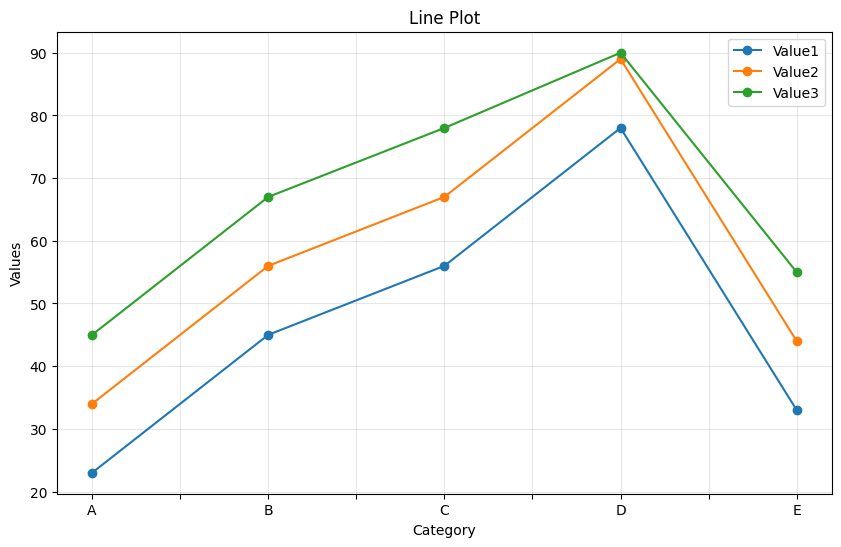

In [172]:
# Create sample data
df_viz = pd.DataFrame({
    'Category': ['A', 'B', 'C', 'D', 'E'],
    'Value1': [23, 45, 56, 78, 33],
    'Value2': [34, 56, 67, 89, 44],
    'Value3': [45, 67, 78, 90, 55]
})

# Line plot
df_viz.set_index('Category').plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Line Plot')
plt.ylabel('Values')
plt.grid(True, alpha=0.3)
plt.show()

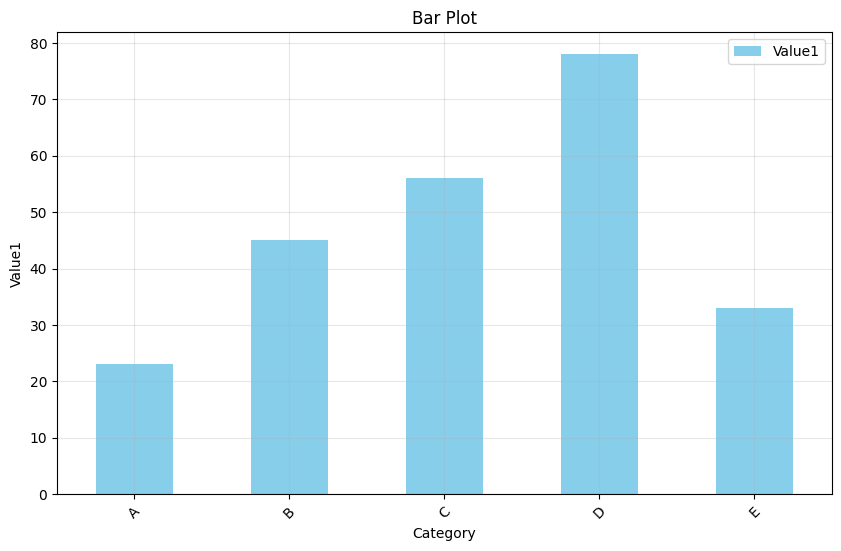

In [173]:
# Bar plot
df_viz.plot(x='Category', y='Value1', kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Bar Plot')
plt.ylabel('Value1')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

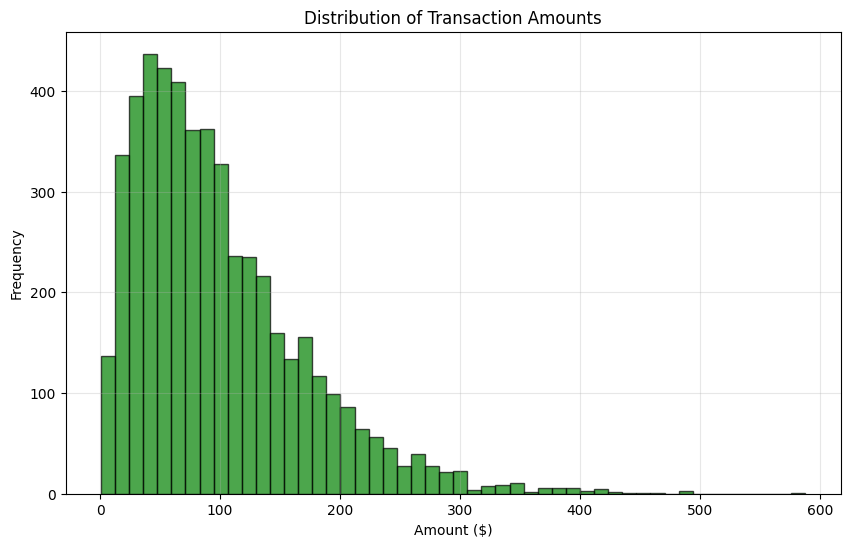

In [174]:
# Histogram from customer transaction data
customer_transactions['amount'].hist(bins=50, figsize=(10, 6), alpha=0.7, color='green', edgecolor='black')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

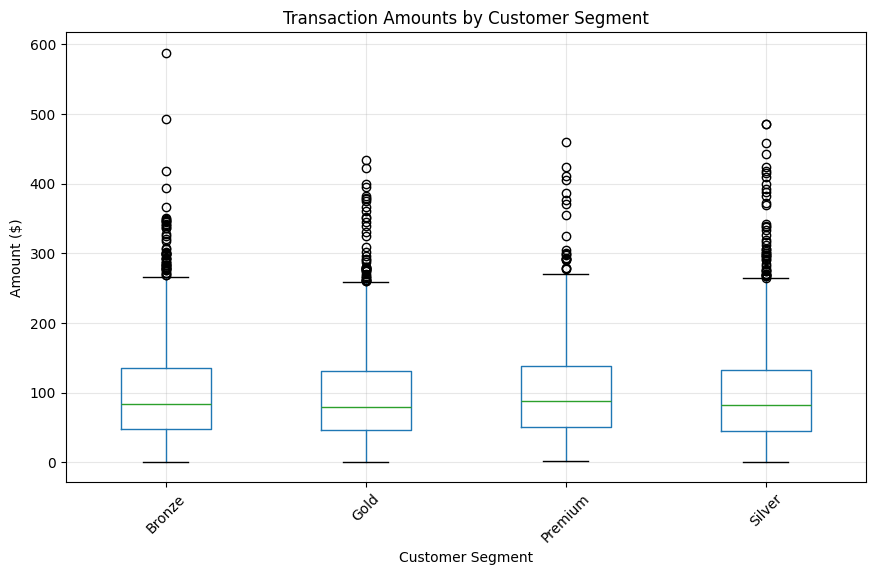

In [175]:
# Box plot by category
df_analysis = customer_transactions.groupby('customer_segment')['amount'].apply(list).reset_index()
customer_transactions.boxplot(column='amount', by='customer_segment', figsize=(10, 6))
plt.title('Transaction Amounts by Customer Segment')
plt.suptitle('')  # Remove default title
plt.xlabel('Customer Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [176]:
# Scatter plot
customer_metrics_sample = customer_metrics.sample(min(500, len(customer_metrics)))
plt.figure(figsize=(10, 6))
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

<Figure size 1000x600 with 0 Axes>